In [171]:
import pandas as pd

# Load demand data
demand_df = pd.read_csv('/content/drive/My Drive/data/electricity_demand/demand.csv')

# Load weather data (e.g., Kobe & Osaka)
kobe_df = pd.read_csv('/content/drive/My Drive/data/Weather/kobe.csv')
osaka_df = pd.read_csv('/content/drive/My Drive/data/Weather/osaka.csv')
hikone_df = pd.read_csv('/content/drive/My Drive/data/Weather/hikone.csv')
kyoto_df = pd.read_csv('/content/drive/My Drive/data/Weather/kyoto.csv')
nara_df = pd.read_csv('/content/drive/My Drive/data/Weather/nara.csv')
shionomisaki_df = pd.read_csv('/content/drive/My Drive/data/Weather/shionomisaki.csv')
toyooka_df = pd.read_csv('/content/drive/My Drive/data/Weather/toyooka.csv')
wakayama_df = pd.read_csv('/content/drive/My Drive/data/Weather/wakayama.csv')

# Display first few rows
print(demand_df.head())
print(wakayama_df.head())


              datetime  actual_performance(10  000 kW)
0  2021-01-01 00:00:00                   1571      NaN
1  2021-01-01 01:00:00                   1492      NaN
2  2021-01-01 02:00:00                   1453      NaN
3  2021-01-01 03:00:00                   1412      NaN
4  2021-01-01 04:00:00                   1358      NaN
              datetime  precipitation  temperature  dew_point_temperature  \
0  2021-01-01 00:00:00            0.0          2.3                   -1.0   
1  2021-01-01 01:00:00            0.0          3.1                   -2.2   
2  2021-01-01 02:00:00            0.0          3.9                   -4.1   
3  2021-01-01 03:00:00            0.0          3.9                   -3.4   
4  2021-01-01 04:00:00            0.0          3.9                   -3.1   

   humidity  wind_speed wind_direction  snowfall  
0      79.0         2.6            西南西       0.0  
1      68.0         1.5              北       0.0  
2      56.0         6.2            西北西       0.0  
3  

In [172]:
print(demand_df.info())  # Check column types
print(demand_df.isnull().sum())  # Check missing values


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26280 entries, 0 to 26279
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   datetime               26280 non-null  object 
 1   actual_performance(10  26280 non-null  int64  
 2   000 kW)                0 non-null      float64
dtypes: float64(1), int64(1), object(1)
memory usage: 616.1+ KB
None
datetime                     0
actual_performance(10        0
000 kW)                  26280
dtype: int64


In [173]:
demand_df.rename(columns={'actual_performance(10': 'actual_performance_kW'}, inplace=True)
# Drop the empty column
demand_df.drop(columns=['000 kW)'], inplace=True)

In [174]:
demand_df.head(5)

,datetime,actual_performance_kW
0,2021-01-01 00:00:00,1571
1,2021-01-01 01:00:00,1492
2,2021-01-01 02:00:00,1453
3,2021-01-01 03:00:00,1412
4,2021-01-01 04:00:00,1358


In [175]:
import pandas as pd

# List of all weather file names
weather_files = ["kobe", "osaka", "hikone", "kyoto", "nara", "shionomisaki", "toyooka", "wakayama"]

# Initialize an empty DataFrame
weather_df = None

for location in weather_files:
    file_path = f"/content/drive/My Drive/data/Weather/{location}.csv"

    try:
        temp_df = pd.read_csv(file_path)
        temp_df['datetime'] = pd.to_datetime(temp_df['datetime'], errors='coerce')

        # Drop any rows with NaT in datetime
        temp_df.dropna(subset=['datetime'], inplace=True)

        if temp_df.empty:
            print(f"Warning: {location}.csv is empty after processing!")
            continue

        # Merge with the main DataFrame
        if weather_df is None:
            weather_df = temp_df  # First file becomes the base
        else:
            weather_df = weather_df.merge(temp_df, on='datetime', suffixes=('', f'_{location}'), how='outer')

    except Exception as e:
        print(f"Error processing {location}.csv: {e}")

# Final check
if weather_df is not None:
    print(weather_df.head(), weather_df.shape)
    weather_df.to_csv('/content/merged_weather.csv', index=False)
else:
    print("No valid weather data files were loaded.")


             datetime  precipitation  temperature  dew_point_temperature  \
0 2021-01-01 00:00:00            0.0          2.2                   -3.7   
1 2021-01-01 01:00:00            0.0          2.5                   -3.4   
2 2021-01-01 02:00:00            0.0          2.1                   -3.2   
3 2021-01-01 03:00:00            0.0          1.5                   -3.9   
4 2021-01-01 04:00:00            0.0          1.8                   -3.7   

   humidity  wind_speed wind_direction  snowfall  precipitation_osaka  \
0      65.0         5.7              西       0.0                  0.0   
1      65.0         4.3            西南西       0.0                  0.0   
2      68.0         4.5              西       0.0                  0.0   
3      67.0         4.5              西       0.0                  0.0   
4      67.0         3.5              西       0.0                  0.0   

   temperature_osaka  ...  wind_speed_toyooka  wind_direction_toyooka  \
0                3.1  ...      

In [176]:
# Ensure datetime format is consistent
demand_df['datetime'] = pd.to_datetime(demand_df['datetime'], errors='coerce')
weather_df['datetime'] = pd.to_datetime(weather_df['datetime'], errors='coerce')


In [177]:
merged_df = demand_df.merge(weather_df, on='datetime', how='left')
merged_df.head()

,datetime,actual_performance_kW,precipitation,temperature,dew_point_temperature,humidity,wind_speed,wind_direction,snowfall,precipitation_osaka,...,wind_speed_toyooka,wind_direction_toyooka,snowfall_toyooka,precipitation_wakayama,temperature_wakayama,dew_point_temperature_wakayama,humidity_wakayama,wind_speed_wakayama,wind_direction_wakayama,snowfall_wakayama
0,2021-01-01 00:00:00,1571,0.0,2.2,-3.7,65.0,5.7,西,0.0,0.0,...,2.1,南南東,1.0,0.0,2.3,-1.0,79.0,2.6,西南西,0.0
1,2021-01-01 01:00:00,1492,0.0,2.5,-3.4,65.0,4.3,西南西,0.0,0.0,...,2.0,南,2.0,0.0,3.1,-2.2,68.0,1.5,北,0.0
2,2021-01-01 02:00:00,1453,0.0,2.1,-3.2,68.0,4.5,西,0.0,0.0,...,3.5,南西,0.0,0.0,3.9,-4.1,56.0,6.2,西北西,0.0
3,2021-01-01 03:00:00,1412,0.0,1.5,-3.9,67.0,4.5,西,0.0,0.0,...,2.2,南南東,2.0,0.0,3.9,-3.4,59.0,5.6,西北西,0.0
4,2021-01-01 04:00:00,1358,0.0,1.8,-3.7,67.0,3.5,西,0.0,0.0,...,2.8,南,0.0,0.0,3.9,-3.1,60.0,5.8,西北西,0.0


In [178]:
merged_df.columns

Index(['datetime', 'actual_performance_kW', 'precipitation', 'temperature',
       'dew_point_temperature', 'humidity', 'wind_speed', 'wind_direction',
       'snowfall', 'precipitation_osaka', 'temperature_osaka',
       'dew_point_temperature_osaka', 'humidity_osaka', 'wind_speed_osaka',
       'wind_direction_osaka', 'snowfall_osaka', 'precipitation_hikone',
       'temperature_hikone', 'dew_point_temperature_hikone', 'humidity_hikone',
       'wind_speed_hikone', 'wind_direction_hikone', 'snowfall_hikone',
       'precipitation_kyoto', 'temperature_kyoto',
       'dew_point_temperature_kyoto', 'humidity_kyoto', 'wind_speed_kyoto',
       'wind_direction_kyoto', 'snowfall_kyoto', 'precipitation_shionomisaki',
       'temperature_shionomisaki', 'dew_point_temperature_shionomisaki',
       'humidity_shionomisaki', 'wind_speed_shionomisaki',
       'wind_direction_shionomisaki', 'snowfall_shionomisaki',
       'precipitation_toyooka', 'temperature_toyooka',
       'dew_point_temperatur

In [179]:
merged_df.rename(columns={
    'precipitation': 'precipitation_kobe',
    'temperature': 'temperature_kobe',
    'dew_point_temperature': 'dew_point_temperature_kobe',
    'humidity': 'humidity_kobe',
    'wind_speed': 'wind_speed_kobe',
    'wind_direction': 'wind_direction_kobe',
    'snowfall': 'snowfall_kobe'

}, inplace=True)

In [180]:
merged_df.columns

Index(['datetime', 'actual_performance_kW', 'precipitation_kobe',
       'temperature_kobe', 'dew_point_temperature_kobe', 'humidity_kobe',
       'wind_speed_kobe', 'wind_direction_kobe', 'snowfall_kobe',
       'precipitation_osaka', 'temperature_osaka',
       'dew_point_temperature_osaka', 'humidity_osaka', 'wind_speed_osaka',
       'wind_direction_osaka', 'snowfall_osaka', 'precipitation_hikone',
       'temperature_hikone', 'dew_point_temperature_hikone', 'humidity_hikone',
       'wind_speed_hikone', 'wind_direction_hikone', 'snowfall_hikone',
       'precipitation_kyoto', 'temperature_kyoto',
       'dew_point_temperature_kyoto', 'humidity_kyoto', 'wind_speed_kyoto',
       'wind_direction_kyoto', 'snowfall_kyoto', 'precipitation_shionomisaki',
       'temperature_shionomisaki', 'dew_point_temperature_shionomisaki',
       'humidity_shionomisaki', 'wind_speed_shionomisaki',
       'wind_direction_shionomisaki', 'snowfall_shionomisaki',
       'precipitation_toyooka', 'temperat

In [181]:
merged_df['hour'] = merged_df['datetime'].dt.hour
merged_df['day'] = merged_df['datetime'].dt.day
merged_df['month'] = merged_df['datetime'].dt.month
merged_df['weekday'] = merged_df['datetime'].dt.weekday

In [182]:
merged_df['demand_rolling_24h'] = merged_df['actual_performance_kW'].rolling(window=24, min_periods=1).mean()
merged_df['demand_rolling_7d'] = merged_df['actual_performance_kW'].rolling(window=24*7, min_periods=1).mean()


In [183]:
for lag in [1, 2, 24, 48]:  # Previous 1h, 2h, 24h, 48h
    merged_df[f'demand_lag_{lag}'] = merged_df['actual_performance_kW'].shift(lag)


In [184]:
merged_df.dropna(inplace=True)

In [185]:
merged_df.head(4)

,datetime,actual_performance_kW,precipitation_kobe,temperature_kobe,dew_point_temperature_kobe,humidity_kobe,wind_speed_kobe,wind_direction_kobe,snowfall_kobe,precipitation_osaka,...,hour,day,month,weekday,demand_rolling_24h,demand_rolling_7d,demand_lag_1,demand_lag_2,demand_lag_24,demand_lag_48
48,2021-01-03 00:00:00,1436,0.0,4.0,-3.0,60.0,6.0,西,0.0,0.0,...,0,3,1,6,1490.875000,1497.632653,1520.0,1565.0,1438.0,1571.0
49,2021-01-03 01:00:00,1384,0.0,3.9,-2.5,63.0,5.7,西,0.0,0.0,...,1,3,1,6,1490.833333,1495.360000,1436.0,1520.0,1385.0,1492.0
50,2021-01-03 02:00:00,1382,0.0,3.2,-2.3,67.0,3.0,西,0.0,0.0,...,2,3,1,6,1490.666667,1493.137255,1384.0,1436.0,1386.0,1453.0
51,2021-01-03 03:00:00,1362,0.0,3.4,-2.5,65.0,4.6,西,0.0,0.0,...,3,3,1,6,1490.625000,1490.615385,1382.0,1384.0,1363.0,1412.0


In [186]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [187]:
sns.set_style("darkgrid")

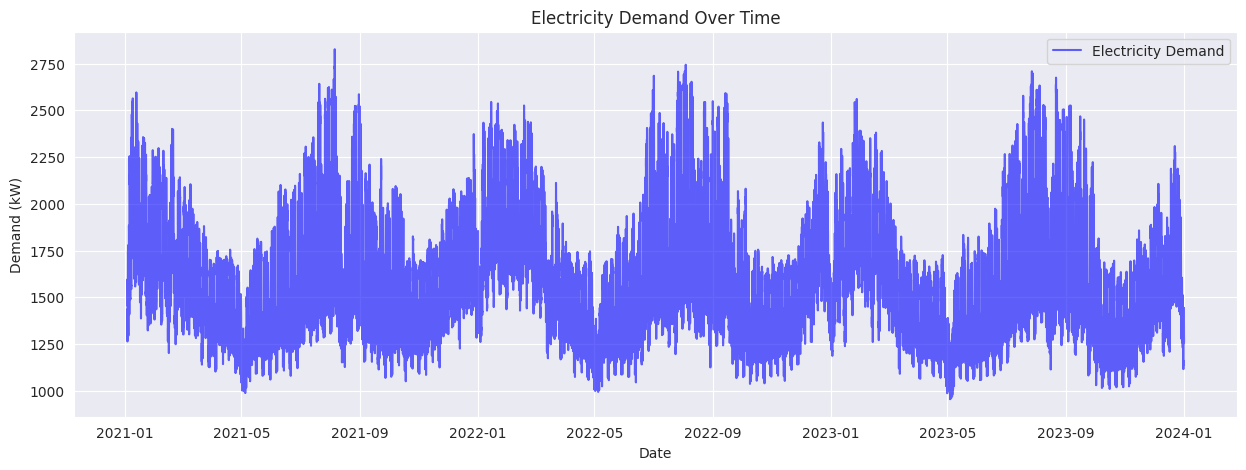

In [188]:
# Plot demand trends over time
plt.figure(figsize=(15, 5))
plt.plot(merged_df['datetime'], merged_df['actual_performance_kW'], label="Electricity Demand", color="blue", alpha=0.6)
plt.xlabel("Date")
plt.ylabel("Demand (kW)")
plt.title("Electricity Demand Over Time")
plt.legend()
plt.show()

<ipython-input-189-333894de0f40>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=merged_df['hour'], y=merged_df['actual_performance_kW'], palette="Blues")


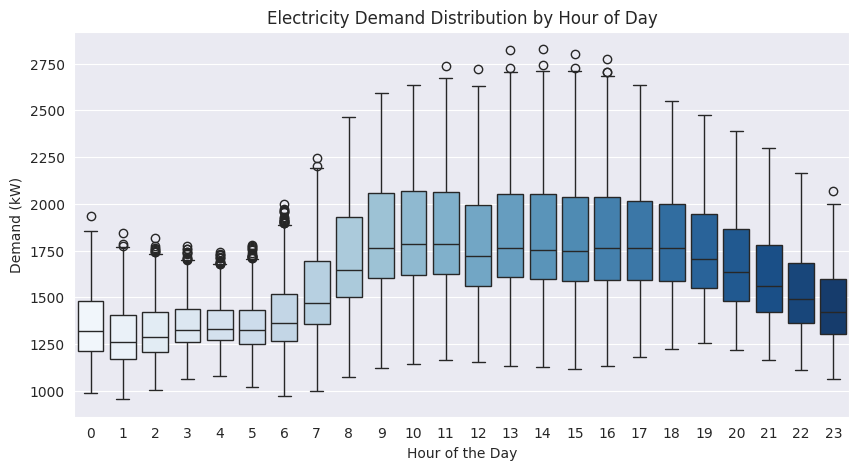

In [189]:
# Plot demand distribution by hour of the day
plt.figure(figsize=(10, 5))
sns.boxplot(x=merged_df['hour'], y=merged_df['actual_performance_kW'], palette="Blues")
plt.xlabel("Hour of the Day")
plt.ylabel("Demand (kW)")
plt.title("Electricity Demand Distribution by Hour of Day")
plt.show()

In [190]:
# Check for non-numeric columns
non_numeric_cols = merged_df.select_dtypes(exclude=['number']).columns.drop('datetime', errors='ignore')
print("Non-numeric columns:", non_numeric_cols)


Non-numeric columns: Index(['wind_direction_kobe', 'wind_direction_osaka', 'wind_direction_hikone',
       'wind_direction_kyoto', 'wind_direction_shionomisaki',
       'wind_direction_toyooka', 'wind_direction_wakayama'],
      dtype='object')


In [191]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
for col in (non_numeric_cols):
    merged_df[col] = label_encoder.fit_transform(merged_df[col].astype(str))


In [192]:
merged_df.head(2)

,datetime,actual_performance_kW,precipitation_kobe,temperature_kobe,dew_point_temperature_kobe,humidity_kobe,wind_speed_kobe,wind_direction_kobe,snowfall_kobe,precipitation_osaka,...,hour,day,month,weekday,demand_rolling_24h,demand_rolling_7d,demand_lag_1,demand_lag_2,demand_lag_24,demand_lag_48
48,2021-01-03 00:00:00,1436,0.0,4.0,-3.0,60.0,6.0,14,0.0,0.0,...,0,3,1,6,1490.875000,1497.632653,1520.0,1565.0,1438.0,1571.0
49,2021-01-03 01:00:00,1384,0.0,3.9,-2.5,63.0,5.7,14,0.0,0.0,...,1,3,1,6,1490.833333,1495.360000,1436.0,1520.0,1385.0,1492.0


In [193]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
weather_features = [col for col in merged_df.columns if col not in ['datetime', 'actual_performance_kW']]
merged_df[weather_features] = scaler.fit_transform(merged_df[weather_features])

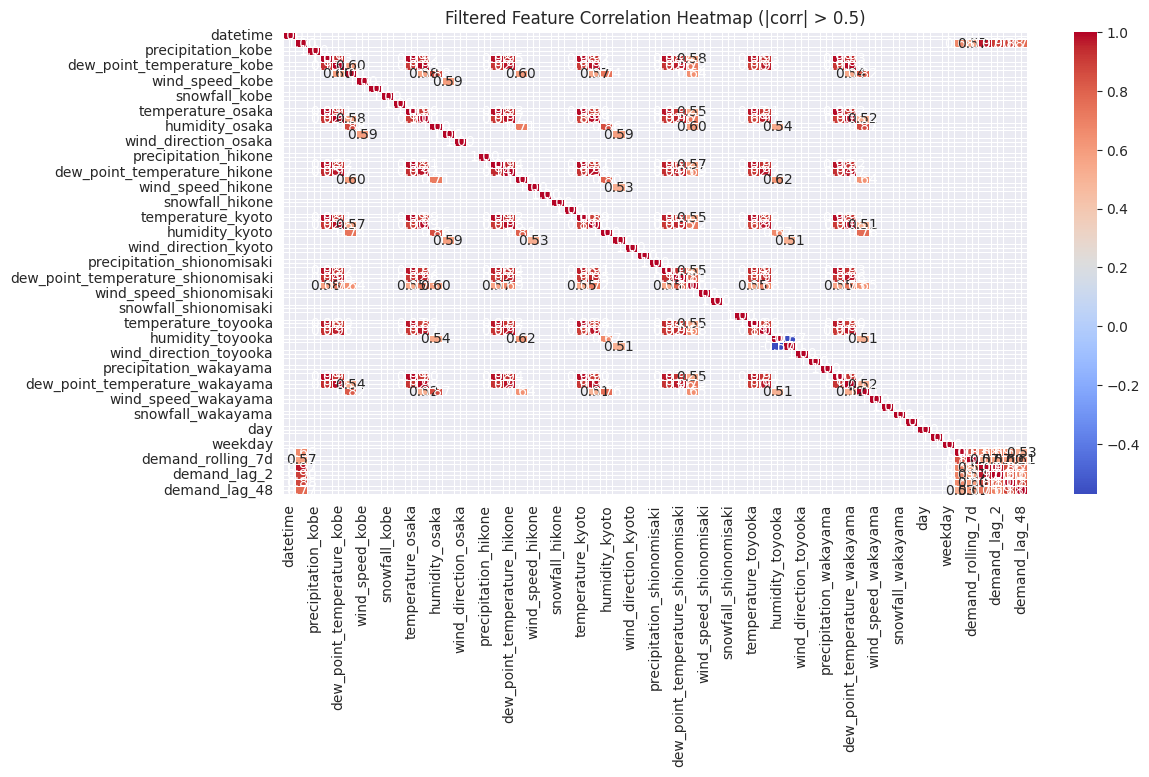

In [194]:
# Compute correlation matrix
corr_matrix = merged_df.corr()

# Set threshold (e.g., 0.5)
threshold = 0.5

# Filter correlations above the threshold
filtered_corr = corr_matrix[(corr_matrix > threshold) | (corr_matrix < -threshold)]

# Plot heatmap for significant correlations
plt.figure(figsize=(12, 6))
sns.heatmap(filtered_corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Filtered Feature Correlation Heatmap (|corr| > 0.5)")
plt.show()



In [195]:
merged_df['datetime'] = pd.to_datetime(merged_df['datetime'], errors='coerce')


In [196]:
train = merged_df[merged_df['datetime'] < '2023-01-01 00:00:00']
test = merged_df[merged_df['datetime'] >= '2023-01-01 00:00:00']
X_train, X_test = train.drop(columns=['actual_performance_kW', 'datetime']), test.drop(columns=['actual_performance_kW', 'datetime'])
y_train, y_test = train['actual_performance_kW'], test['actual_performance_kW']

** Model Development for Electricity Demand Forecasting**

 Used *XGBoost (eXtreme Gradient Boosting) *as it
*   Captures Non-linear Trends effectively
*   Automatically prioritizes important features.
*   Has Faster training compared to deep learning models

Feature Engineering

*   Time-based Features: Hour, day, month, and weekday to capture demand cycles.List item
*   Weather Data: Uses temperature, humidity, wind direction (converted to numeric), and pressure for better accuracy.






In [197]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [198]:
# XGBoost Model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.01, max_depth=7,
    random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

In [199]:
xgb_preds

array([1484.8698, 1438.8638, 1446.944 , ..., 1447.9353, 1416.208 ,
       1379.392 ], dtype=float32)

In [200]:
from sklearn.metrics import mean_absolute_error, r2_score

# Compute additional metrics
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_preds))
mape_xgb = np.mean(np.abs((y_test - xgb_preds) / y_test)) * 100
r2_xgb = r2_score(y_test, xgb_preds)

print(f'RMSE XGBoost: {rmse_xgb}')
print(f'MAPE XGBoost: {mape_xgb:.2f}%')
print(f'R² XGBoost: {r2_xgb}')



RMSE XGBoost: 128.31782745881415
MAPE XGBoost: 6.89%
R² XGBoost: 0.8493457436561584


**Evaluation of Forecasting Performance Using Actual Data**

**Selected Evaluation Metric **


1.  Root Mean Squared Error (RMSE)
    
    -RMSE penalizes large errors more than smaller ones, making it suitable for forecasting tasks.
2.  Mean Absolute Percentage Error (MAPE)
    
    -Useful for understanding the relative accuracy of predictions
3.  R² Score
    
    -Represents the proportion of variance explained by the model.




**Error Analysis and Model Challenges**


1.   Overfitting Concerns
2.   Residual Analysis
3.   Feature Engineering Limitations



**Issues Identified Through Error Analysis**

-**Peak Demand Errors:**

The model struggles with high-demand periods, leading to increased residuals.

-**Weather Feature Impact:**

Wind direction encoding and other weather parameters may not be fully captured in their effect on demand.

-**Lag Feature Limitations:**

Some lag-based features may cause missing values, reducing the training data.

-**Overfitting Concerns:**

A high R² value suggests a good fit but might not generalize well to unseen data.

**Hypotheses for Accuracy Improvement
Enhanced Feature Engineering:**

1. Include additional time-based features such as seasonality indicators and holiday flags.
Create interaction terms between temperature, humidity, and wind speed.

2. Handling External Influences:
Incorporate economic and industrial activity data that may affect electricity demand.
Consider demand shifts during extreme weather events.

3. Advanced Data Preprocessing:
Improve handling of missing values using imputation techniques.
Refine encoding strategies for categorical variables like wind direction.

4. Hyperparameter Tuning:
Optimize XGBoost parameters using grid search or Bayesian optimization.
Adjust learning rate, tree depth, and regularization terms for better generalization.

**Expected Benefits of Model Deployment**

**Improved Forecast Accuracy**

 -Provides more reliable electricity demand predictions, helping grid operators manage supply efficiently.

 -Reduces overproduction and underproduction risks, leading to cost savings.